In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [4]:
# load the dataset
df = pd.read_csv("/insurance.csv")
print("Dataset loaded successfully!")
print()

Dataset loaded successfully!



In [7]:
# display basic information
print("First 5 rows:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("Column Names:")
print(df.columns)

print("\nDataTypes:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nStatistical Summary:")
print(df.describe())


First 5 rows:
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520

Dataset Shape:
(1338, 7)
Column Names:
Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

DataTypes:
age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

Missing Values:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Statistical Summary:
               age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.09

In [8]:
# select independent and dependent variables
X = df[["age"]]
y = df["charges"]
print("\nIndependent Variable:")
print("AGE")

print("\nDependent Variable:")
print("Charges")


Independent Variable:
AGE

Dependent Variable:
Charges


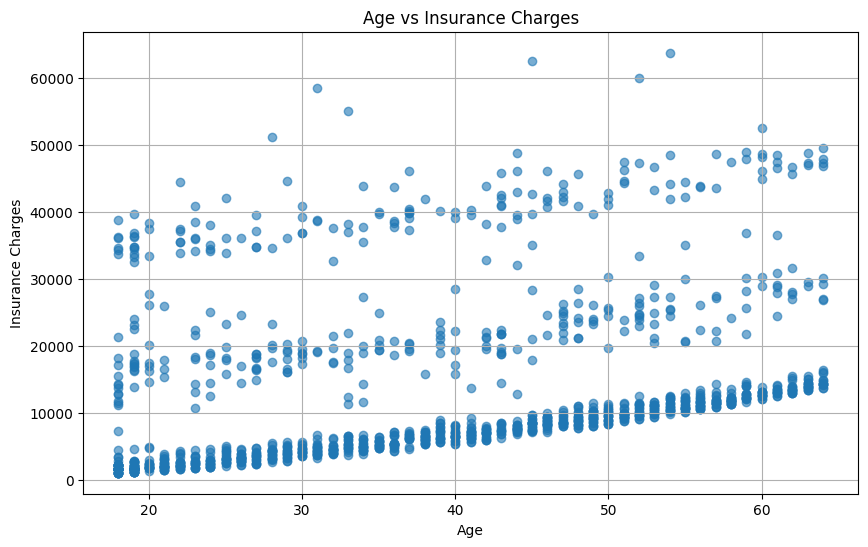

In [10]:
# visualize original data
plt.figure(figsize = (10,6))
plt.scatter(X["age"],y,alpha = 0.6)
plt.xlabel("Age")
plt.ylabel("Insurance Charges")
plt.title("Age vs Insurance Charges")
plt.grid(True)
plt.show()

In [11]:
# split data into training(80) and testing(20) data
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42)
print("\nTraining samples:",len(X_train))
print("\nTesting samples:",len(X_test))




Training samples: 1070

Testing samples: 268


In [12]:
# simple linear regression
# degree  = 1
linear_model = LinearRegression()
linear_model.fit(X_train,y_train)
y_pred_linear = linear_model.predict(X_test)
print("\n==============================")
print("LINEAR REGRESSION")
print("==============================")
print("Slope:",linear_model.coef_[0])
print("Intercept:",linear_model.intercept_)
print("R2 Score:",r2_score(y_test,y_pred_linear))
print("Mean Absolute Error:",mean_absolute_error(y_test, y_pred_linear))
print("Mean Squared Error:",mean_squared_error(y_test, y_pred_linear))
print("Root Mean Squared Error:",np.sqrt(mean_squared_error(y_test, y_pred_linear)))


LINEAR REGRESSION
Slope: 240.59655978877493
Intercept: 3876.928684191691
R2 Score: 0.12408973539501944
Mean Absolute Error: 9173.258196746589
Mean Squared Error: 135983957.4805469
Root Mean Squared Error: 11661.21595205864


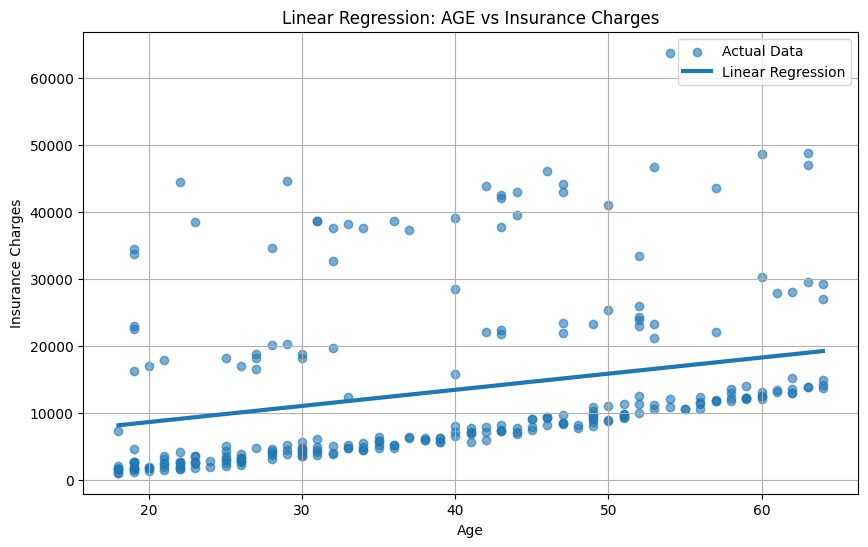

In [14]:
# visualize linear regression
plt.figure(figsize = (10,6))
plt.scatter(X_test["age"],y_test,alpha = 0.6, label = "Actual Data")
# sort values for smooth regression line
sort_index = np.argsort(X_test["age"].values)
X_test_sorted = X_test.iloc[sort_index]
y_linear_sorted = linear_model.predict(X_test_sorted)
plt.plot(X_test_sorted["age"],y_linear_sorted,linewidth = 3,label = "Linear Regression")
plt.xlabel("Age")
plt.ylabel("Insurance Charges")
plt.title("Linear Regression: AGE vs Insurance Charges")
plt.legend()
plt.grid(True)
plt.show()

In [18]:
def polynomial_regression(degree):

    # Create polynomial features
    poly = PolynomialFeatures(
        degree=degree,
        include_bias=False
    )

    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    # Create Linear Regression model
    model = LinearRegression()

    # Train the model
    model.fit(X_train_poly, y_train)

    # Predictions
    y_train_pred = model.predict(X_train_poly)
    y_test_pred = model.predict(X_test_poly)

    # Calculate evaluation values
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    test_mae = mean_absolute_error(y_test, y_test_pred)

    test_mse = mean_squared_error(y_test, y_test_pred)

    test_rmse = np.sqrt(test_mse)

    return (
        poly,
        model,
        y_test_pred,
        train_r2,
        test_r2,
        test_mae,
        test_mse,
        test_rmse
    )




In [19]:
# Train Polynomial Models
degrees = [2, 3, 4, 5]

results = []

for degree in degrees:

    (
        poly,
        model,
        predictions,
        train_r2,
        test_r2,
        mae,
        mse,
        rmse
    ) = polynomial_regression(degree)

    results.append([
        degree,
        train_r2,
        test_r2,
        mae,
        mse,
        rmse
    ])



In [20]:
# Display Comparison Table
results_df = pd.DataFrame(
    results,
    columns=[
        "Degree",
        "Training R2",
        "Testing R2",
        "MAE",
        "MSE",
        "RMSE"
    ]
)

print("\n==============================")
print("POLYNOMIAL REGRESSION RESULTS")
print("==============================")

print(results_df)
3


POLYNOMIAL REGRESSION RESULTS
   Degree  Training R2  Testing R2          MAE           MSE          RMSE
0       2     0.082001    0.118737  9189.477865  1.368150e+08  11696.794604
1       3     0.082504    0.118542  9195.254663  1.368453e+08  11698.090123
2       4     0.082528    0.119201  9190.466273  1.367429e+08  11693.712258
3       5     0.084087    0.118720  9197.492201  1.368176e+08  11696.906368


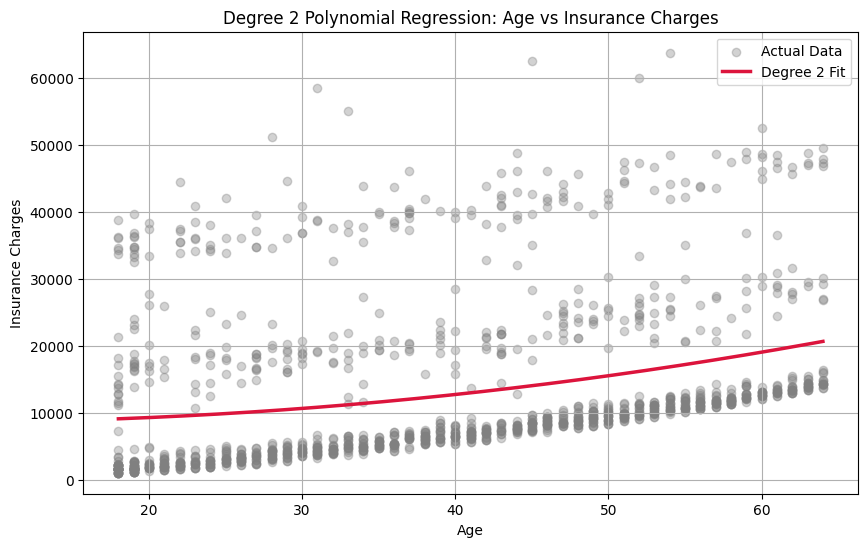

In [26]:
# Degree 2 Polynomial Regression
poly2 = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly2 = poly2.fit_transform(X_train)

model2 = LinearRegression()
model2.fit(X_train_poly2, y_train)

# Create smooth range of Age for plotting
age_range = np.linspace(X["age"].min(), X["age"].max(), 300).reshape(-1, 1)
age_range_df = pd.DataFrame(age_range, columns=["age"])
y_pred_range2 = model2.predict(poly2.transform(age_range_df))

# Plot
plt.figure(figsize=(10, 6))
plt.scatter(X["age"], y, alpha=0.35, color="gray", label="Actual Data")
plt.plot(age_range, y_pred_range2, color="crimson", linewidth=2.5, label="Degree 2 Fit")
plt.xlabel("Age")
plt.ylabel("Insurance Charges")
plt.title("Degree 2 Polynomial Regression: Age vs Insurance Charges")
plt.legend()
plt.grid(True)
plt.show()


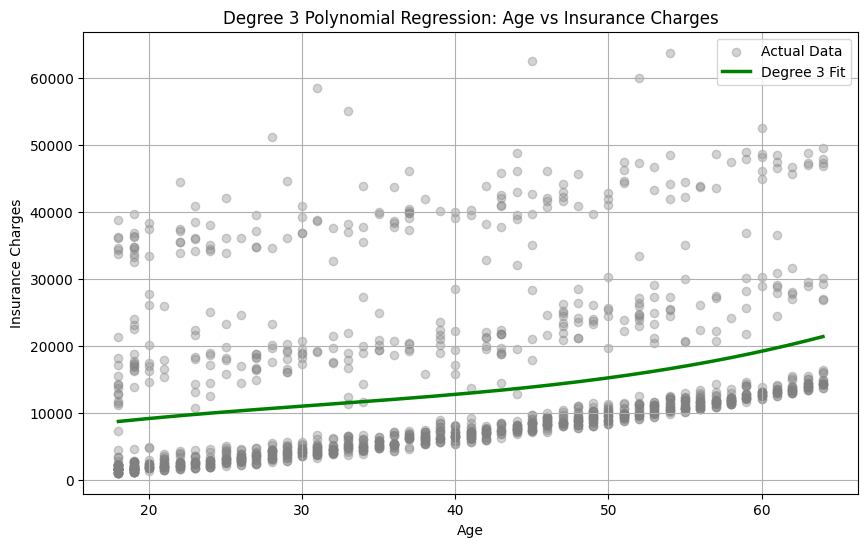

In [27]:
# Degree 3 Polynomial Regression
poly3 = PolynomialFeatures(degree=3, include_bias=False)
X_train_poly3 = poly3.fit_transform(X_train)

model3 = LinearRegression()
model3.fit(X_train_poly3, y_train)

# Create smooth range of Age for plotting
y_pred_range3 = model3.predict(poly3.transform(age_range_df))

# Plot
plt.figure(figsize=(10, 6))
plt.scatter(X["age"], y, alpha=0.35, color="gray", label="Actual Data")
plt.plot(age_range, y_pred_range3, color="green", linewidth=2.5, label="Degree 3 Fit")
plt.xlabel("Age")
plt.ylabel("Insurance Charges")
plt.title("Degree 3 Polynomial Regression: Age vs Insurance Charges")
plt.legend()
plt.grid(True)
plt.show()

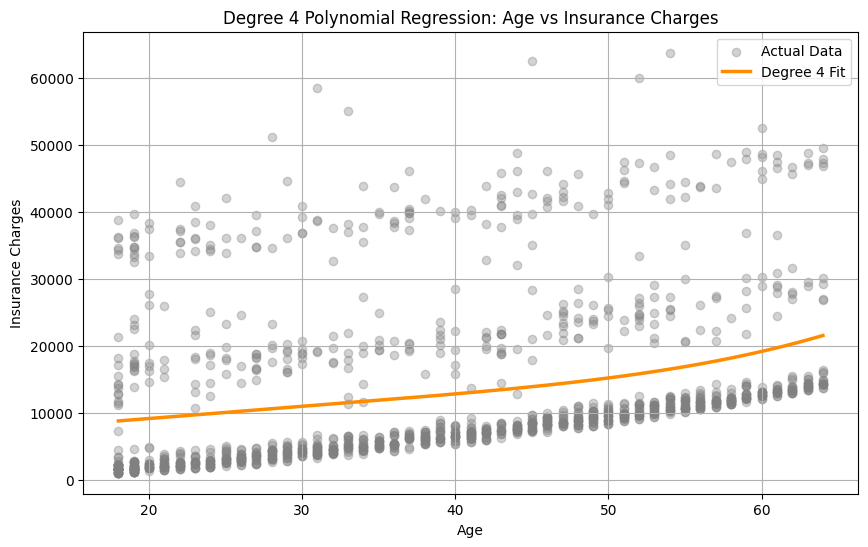

In [28]:
# Degree 4 Polynomial Regression
poly4 = PolynomialFeatures(degree=4, include_bias=False)
X_train_poly4 = poly4.fit_transform(X_train)

model4 = LinearRegression()
model4.fit(X_train_poly4, y_train)

# Create smooth range of Age for plotting
y_pred_range4 = model4.predict(poly4.transform(age_range_df))

# Plot
plt.figure(figsize=(10, 6))
plt.scatter(X["age"], y, alpha=0.35, color="gray", label="Actual Data")
plt.plot(age_range, y_pred_range4, color="darkorange", linewidth=2.5, label="Degree 4 Fit")
plt.xlabel("Age")
plt.ylabel("Insurance Charges")
plt.title("Degree 4 Polynomial Regression: Age vs Insurance Charges")
plt.legend()
plt.grid(True)
plt.show()

In [23]:
# Predict Insurance Charges for a new Age
new_age = np.array([[30]])

print("\n==============================")
print("PREDICTION FOR NEW Age")
print("==============================")


for degree in [2, 3, 4, 5]:

    poly = PolynomialFeatures(
        degree=degree,
        include_bias=False
    )

    X_train_poly = poly.fit_transform(X_train)

    model = LinearRegression()

    model.fit(X_train_poly, y_train)

    new_age_poly = poly.transform(new_age)

    predicted_charge = model.predict(new_age_poly)

    print(
        f"Degree {degree}: "
        f"Predicted insurance charge = "
        f"{predicted_charge[0]:.2f}"
    )




PREDICTION FOR NEW Age
Degree 2: Predicted insurance charge = 10711.40
Degree 3: Predicted insurance charge = 11054.74
Degree 4: Predicted insurance charge = 11019.27
Degree 5: Predicted insurance charge = 10691.72


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


In [30]:
# Display Polynomial Features
poly_demo = PolynomialFeatures(
    degree=3,
    include_bias=False
)

demo_features = poly_demo.fit_transform(
    np.array([[20], [25], [30]])
)

demo_df = pd.DataFrame(
    demo_features,
    columns=["Age", "Age²", "Age³"]
)

print("\n==============================")
print("POLYNOMIAL FEATURE GENERATION")
print("==============================")

print(demo_df)



POLYNOMIAL FEATURE GENERATION
    Age   Age²     Age³
0  20.0  400.0   8000.0
1  25.0  625.0  15625.0
2  30.0  900.0  27000.0


In [31]:
# ============================================================
# STEP 15: FINAL ACCURACY & METRICS SUMMARY (NUMERICAL OUTPUT)
# ============================================================

print('\n' + '=' * 52)
print('         FINAL MODEL ACCURACY & PERFORMANCE        ')
print('=' * 52)

for index, row in results_df.iterrows():
  deg = int(row['Degree'])
  train_r2 = row['Training R2']
  test_r2 = row['Testing R2']
  mae = row['MAE']
  rmse = row['RMSE']

  print(f'\n--- DEGREE {deg} ---')
  print(
      f'  Training Accuracy (R² Score) : {train_r2:.4f} ({train_r2 * 100:.2f}%)'
  )
  print(
      f'  Testing Accuracy  (R² Score) : {test_r2:.4f} ({test_r2 * 100:.2f}%)'
  )
  print(f'  Mean Absolute Error (MAE)   : ${mae:,.2f}')
  print(f'  Root Mean Sq. Error (RMSE)  : ${rmse:,.2f}')

# Automatically highlight the best degree based on highest Test R² score
best_model = results_df.loc[results_df['Testing R2'].idxmax()]

print('\n' + '=' * 52)
print('                     VERDICT                      ')
print('=' * 52)
print(f' Best Performing Degree       : Degree {int(best_model["Degree"])}')
print(
    ' Highest Testing Accuracy (R²):'
    f' {best_model["Testing R2"]:.4f} ({best_model["Testing R2"] * 100:.2f}%)'
)
print(f' Lowest Test Error (RMSE)     : ${best_model["RMSE"]:,.2f}')
print('=' * 52)


         FINAL MODEL ACCURACY & PERFORMANCE        

--- DEGREE 2 ---
  Training Accuracy (R² Score) : 0.0820 (8.20%)
  Testing Accuracy  (R² Score) : 0.1187 (11.87%)
  Mean Absolute Error (MAE)   : $9,189.48
  Root Mean Sq. Error (RMSE)  : $11,696.79

--- DEGREE 3 ---
  Training Accuracy (R² Score) : 0.0825 (8.25%)
  Testing Accuracy  (R² Score) : 0.1185 (11.85%)
  Mean Absolute Error (MAE)   : $9,195.25
  Root Mean Sq. Error (RMSE)  : $11,698.09

--- DEGREE 4 ---
  Training Accuracy (R² Score) : 0.0825 (8.25%)
  Testing Accuracy  (R² Score) : 0.1192 (11.92%)
  Mean Absolute Error (MAE)   : $9,190.47
  Root Mean Sq. Error (RMSE)  : $11,693.71

--- DEGREE 5 ---
  Training Accuracy (R² Score) : 0.0841 (8.41%)
  Testing Accuracy  (R² Score) : 0.1187 (11.87%)
  Mean Absolute Error (MAE)   : $9,197.49
  Root Mean Sq. Error (RMSE)  : $11,696.91

                     VERDICT                      
 Best Performing Degree       : Degree 4
 Highest Testing Accuracy (R²): 0.1192 (11.92%)
 Lowes